In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import leidenalg
import squidpy as sq
from scipy import sparse
from matplotlib.colors import ListedColormap
import os
import geopandas as gpd
import decoupler as dc
from scipy.io import mmread
from sklearn.utils import sparsefuncs
import scipy.sparse as sp

In [4]:
sample = "Pat2_W4"

um = '008'
print ("Reading in segmentation for sample " + sample)
data_directory = "../segmentation/" + sample + "/"
adata = anndata.read_h5ad(data_directory + sample + "_" + um + ".h5ad")
adata

Reading in segmentation for sample Pat2_W4


AnnData object with n_obs × n_vars = 83320 × 18085
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

In [5]:
sc.pp.filter_cells(adata, min_genes=5)
sc.pp.filter_genes(adata, min_cells=5)

#remove cells with high mitochondrial content
mito_genes = adata.var_names.str.startswith('MT-')
adata.obs['percent_mito'] = np.sum(adata[:, mito_genes].X, axis=1) / np.sum(adata.X, axis=1)
adata = adata[adata.obs['percent_mito'] < 0.05, :]

#remove mitochondrial genes
adata = adata[:, [gene for gene in adata.var_names if not gene.startswith('MT-')]]
adata

View of AnnData object with n_obs × n_vars = 57524 × 15181
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'percent_mito'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    obsm: 'spatial'

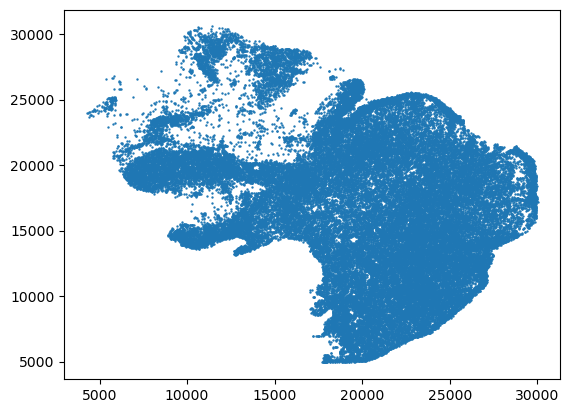

In [6]:
plt.scatter(adata.obsm["spatial"][:,0], adata.obsm["spatial"][:,1], s=0.5)

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata)

/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [8]:
# PCA
sc.tl.pca(adata)
# Compute nearest neighbors
sc.pp.neighbors(adata)
# UMAP for visualization
sc.tl.umap(adata)

2025-03-21 10:27:32.622907: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-21 10:27:32.642948: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-21 10:27:32.665911: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-21 10:27:32.672703: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-21 10:27:32.688999: I tensorflow/core/platform/cpu_feature_guar

/tmp/ipykernel_220906/2521913522.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


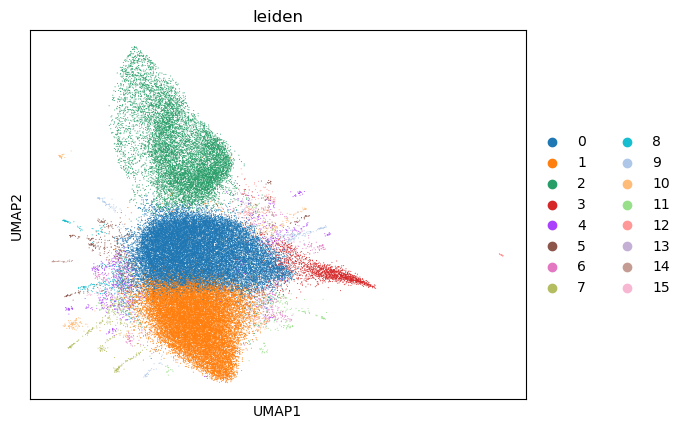

In [9]:
# Clustering
sc.tl.leiden(adata, resolution=0.5)  

# Visualize clusters
sc.pl.umap(adata, color=["leiden"])

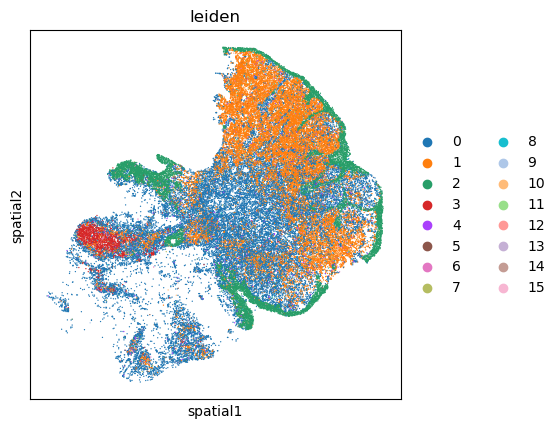

In [10]:
sc.pl.spatial(adata, color='leiden', spot_size=100, alpha_img=1)

In [11]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value enco

In [12]:
adata.obs["leiden"].value_counts()

0     23389
1     19322
2      9678
3      1655
4       689
5       452
6       431
7       390
8       361
9       326
10      308
11      225
12      161
13       59
14       52
15       26
Name: leiden, dtype: int64

In [13]:
clusters = adata.obs['leiden'].unique()
de_results = {}
for cluster in clusters:
    cluster_results = pd.DataFrame({
        'gene': adata.uns['rank_genes_groups']['names'][cluster],
        'logfoldchanges': adata.uns['rank_genes_groups']['logfoldchanges'][cluster],
        'pvals': adata.uns['rank_genes_groups']['pvals'][cluster],
        'pvals_adj': adata.uns['rank_genes_groups']['pvals_adj'][cluster]
    })

    #cluster_results = cluster_results[cluster_results['logfoldchanges'] > 0]
    de_results[cluster] = cluster_results

#print the top 20 genes for each cluster sorted by p-value
for cluster, results in de_results.items():
    print(f"Cluster {cluster}")
    print(results.head(50))
    print("\n")

Cluster 1
         gene  logfoldchanges          pvals      pvals_adj
0       S100B             NaN  1.504956e-116  2.284674e-112
1    SERPINE2             NaN   3.462252e-87   2.628022e-83
2         VIM             NaN   4.098647e-69   1.555539e-65
3       CSRP1             NaN   2.715241e-67   8.244016e-64
4     ALDH1A3             NaN   1.149361e-53   2.492636e-50
5         MGP             NaN   2.346780e-40   3.562647e-37
6         A2M             NaN   3.959048e-26   5.008526e-23
7        SYNM             NaN   9.368326e-25   1.094004e-21
8        APOE             NaN   1.284697e-24   1.393070e-21
9         MIA             NaN   1.740598e-24   1.651501e-21
10       GAS7             NaN   2.575889e-17   1.700199e-14
11  HNRNPA2B1             NaN   3.125451e-17   1.976978e-14
12      SPARC             NaN   1.619385e-15   9.833552e-13
13      CCNL2             NaN   9.969150e-15   5.820833e-12
14       SNX1             NaN   3.920285e-14   2.125494e-11
15      SPRY4             NaN 

In [14]:
# Pat03_W4
cell_type_names = {
    "0": "TME", 
    "1": "Melanocytes",
    "2": "TME",
    "3": "TME",
    "4": "TME",
    "5": "TME",
    "6": "TME",
    "7": "TME",
    "8": "TME",
    "9": "TME",
    "10": "TME",
    "11": "TME",
    "12": "TME",
    "13": "TME",
    "14": "TME",
    "15": "TME"
}

adata.obs["cell_type"] = adata.obs["leiden"].astype(str).map(cell_type_names)

In [15]:
adata.obs["cell_annotation"] = np.where(
    adata.obs["cell_type"] == "Melanocytes", "Tumor", "TME")

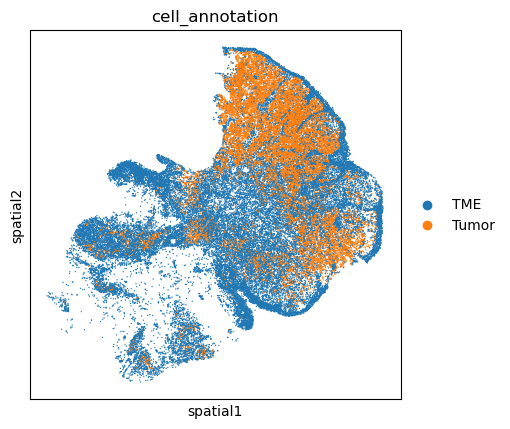

In [17]:
sc.pl.spatial(adata, color='cell_annotation', spot_size=100, alpha_img=1)

In [18]:
adata.write(data_directory + sample + "_" + um + "_processed.h5ad")